This notebook the surface crevasse depth/basal crevasse height calculations in submitted paper: <br />
"Comprehensive Assessment of Stress Calculations for Crevasse Depths and Testing with Crevasse Penetration as Damage". <br />

The notebook first reproduces the figure 4e plot of basal crevasse height versus min prin to max prin strain rate ratio and then makes the plots of this ratio and crevasse penetraion for the Scar Inlet (Larsen B remnant) or Pine Island Glacier ice shelf (Figures 4, 5, and 6).

crevMathFuncs.py contains the function nyeCrevassesAF, which calculates surface crevasse depths and basal crevasse heights with the zero stress approximation with any stress calculation version from inputs of surface and base temperatures, velocity (SSA), and thickness. 

Author: Ben Reynolds (May 14, 2025)

In [6]:
# import libraries
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['figure.dpi'] = 100

from bin.crevMathFuncs import *

In [7]:
# set physical variables
rho_i = 917 # ice density (kg/m^3)
rho_pw = 1027 # proglacial (ocean) water density (kg/m^3)
g = 9.81 # grav accel (m/s^2)
yts = 365.25*24*60*60 # conversion for years to seconds


The below cell remakes Figure 4e, a plot of predicted basal crevasse height with each calculation for a range of strain rate states.

(-2.0, 1.0)

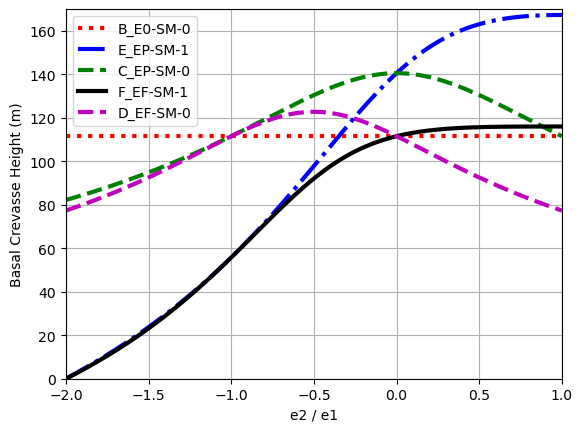

In [8]:
# make vectors of strain rates
e_dot_1 = np.ones([200]) * (.0117 / yts) # max prin strain rate (1/s)
e_dot_2 = np.linspace(-2,1,200) * (.0117 / yts) # min prin strain rate (1/s)
min_over_max_plot = e_dot_2 / e_dot_1 # the x axis for the plot

# get ice rigidity for -2 C
T_b_plot = np.array([-2.0]) # assumed temp (deg C)
B_b_plot = AofT(T_b_plot) ** (-1/3)

# calculate the effective strain rate for 
e_eff_plan = eff_strain_rate(e_dot_1, e_dot_2, 0, 0, 0, 0)
e_eff_full = eff_strain_rate(e_dot_1, e_dot_2, -e_dot_1-e_dot_2, 0, 0, 0)

# calc deviatoric stress components
tau_1_B = B_b_plot * e_dot_1**(1/3)
tau_1_plan = B_b_plot * e_eff_plan**(1/3 - 1) * e_dot_1
tau_2_plan = B_b_plot * e_eff_plan**(1/3 - 1) * e_dot_2
tau_1_full = B_b_plot * e_eff_full**(1/3 - 1) * e_dot_1
tau_2_full = B_b_plot * e_eff_full**(1/3 - 1) * e_dot_2

# calc resistive stresses
Rxx_b_B = 2 * tau_1_B
Rxx_b_C = 2 * tau_1_plan
Rxx_b_D = 2 * tau_1_full
Rxx_b_E = 2 * tau_1_plan + tau_2_plan
Rxx_b_F = 2 * tau_1_full + tau_2_full

# calc basal crevasse heights
ds_B_lin = zero_stress_basal(rho_i, rho_pw, g, Rxx_b_B, 0)
ds_C_lin = zero_stress_basal(rho_i, rho_pw, g, Rxx_b_C, 0)
ds_D_lin = zero_stress_basal(rho_i, rho_pw, g, Rxx_b_D, 0)
ds_E_lin = zero_stress_basal(rho_i, rho_pw, g, Rxx_b_E, 0)
ds_F_lin = zero_stress_basal(rho_i, rho_pw, g, Rxx_b_F, 0)

# plot
fig, axs = plt.subplots(1, 1)
axs.plot(min_over_max_plot, ds_B_lin, 'r:', linewidth=3, label = 'B_E0-SM-0')
axs.plot(min_over_max_plot, ds_E_lin, 'b-.', linewidth=3, label = 'E_EP-SM-1')
axs.plot(min_over_max_plot, ds_C_lin, 'g--', linewidth=3, label = 'C_EP-SM-0')
axs.plot(min_over_max_plot, ds_F_lin, 'k', linewidth=3, label = 'F_EF-SM-1')
axs.plot(min_over_max_plot, ds_D_lin, 'm--', linewidth=3, label = 'D_EF-SM-0')
axs.legend()
plt.xlabel('e2 / e1')
plt.ylabel('Basal Crevasse Height (m)')
axs.grid(True)
axs.xaxis.set_ticks(np.arange(-2, 1.001, .5))
plt.ylim([0,170])
plt.xlim([-2,1])

# #This section outputs a csv file of the results if uncommented.
#to_df = {'e2_to_e1': min_over_max_plot, 'calc_B': ds_B_lin, 'calc_C': ds_C_lin, 'calc_D': ds_D_lin, 'calc_E': ds_E_lin, 'calc_F': ds_F_lin}
#bas_crev_df = pd.DataFrame(data=to_df)
#bas_crev_df.to_csv('bas_crev.csv', index=False)  

User input in below cell to select which shelf to plot. Premade options are: <br />
1. 'larB_2014_2017.nc' = Larsen B remnant with bedmachine surface elevation / thickness and MEaSUREs 2014-2017 velocity mosaic <br />
2. 'PIG_2015.nc' = Pine Island Glacier's ice shelf with bedmachine surface elevation / thickness and ITS_LIVE 2015 velocity mosaic

In [9]:
# data input 

# Uncomment (delete apostraphes) below for Scar Inlet (Larsen B Remnant)

fi_in = './data/Scar_2014_2017.nc'
x_min = -2380e3
x_max = -2310e3
y_min = 1215e3
y_max = 1285e3

'''
# Uncomment below for Pine Island Glacier's Shelf
fi_in = './data/PIG_2015.nc'
x_min = -1650e3
x_max = -1550e3
y_min = -350e3
y_max = -250e3
'''


"\n# Uncomment below for Pine Island Glacier's Shelf\nfi_in = './data/PIG_2015.nc'\nx_min = -1650e3\nx_max = -1550e3\ny_min = -350e3\ny_max = -250e3\n"

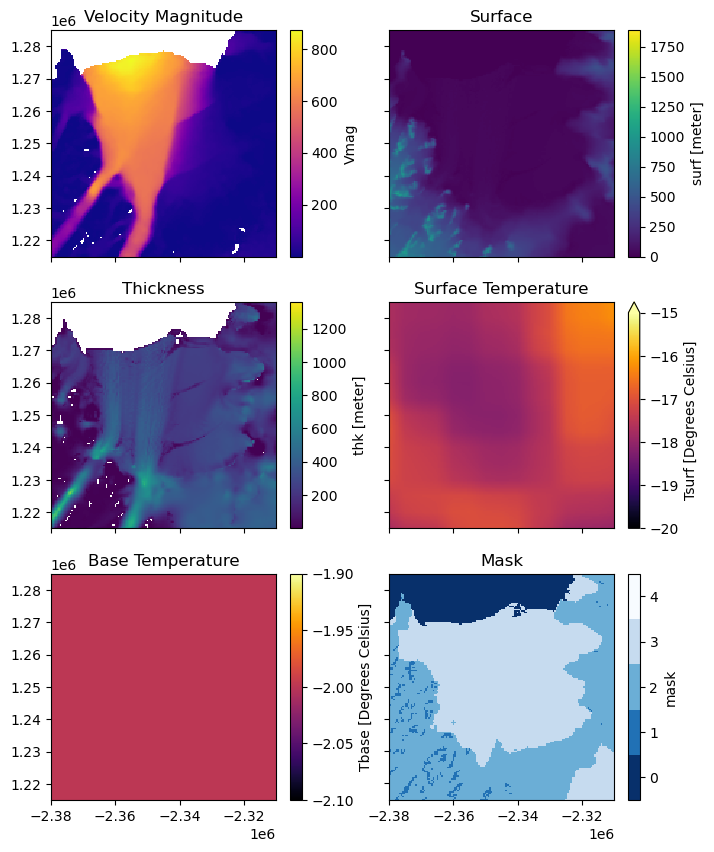

In [10]:
# load and plot the example data

# open the netCDF with xarray
data_xr = xr.open_dataset(fi_in, decode_times=False) 

# calculate velocity magnitude for plotting
data_xr['Vmag'] = np.sqrt(data_xr.VX**2 + data_xr.VY**2)

# Plot data inputs
fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, figsize=(8,10))
data_xr.Vmag.plot(ax=axs[0,0],cmap=plt.cm.plasma)
axs[0,0].set_title('Velocity Magnitude')

data_xr.surf.plot(ax=axs[0,1],cmap=plt.cm.viridis)
axs[0,1].set_title('Surface')

data_xr.thk.plot(ax=axs[1,0],cmap=plt.cm.viridis)
axs[1,0].set_title('Thickness')

data_xr.Tsurf.plot(ax=axs[1,1],cmap=plt.cm.inferno,  vmin=-20, vmax=-15)
axs[1,1].set_title('Surface Temperature')

data_xr.Tbase.plot(ax=axs[2,0],cmap=plt.cm.inferno)
axs[2,0].set_title('Base Temperature')

cmap_mask = plt.get_cmap('Blues_r', 4 - 0 + 1)
mask_plt = data_xr.mask.plot(ax=axs[2,1],cmap=cmap_mask, vmin=0 - 0.5, vmax=4 + 0.5)
axs[2,1].set_title('Mask')
#plt.colorbar(mask_plt, ticks=np.arange(0, 4 + 1))

# reomve axis labels
for i in range(0,3):
    for j in range(0,2):
        axs[i,j].set_xlabel('')
        axs[i,j].set_ylabel('')

# set axis bounds
axs[2,1].set_xlim(x_min, x_max)
axs[2,1].set_ylim(y_min, y_max)
axs[2,1].set_aspect('equal')


In [11]:
# make numpy arrays from xarray dataset. Flip the 
X = np.array(data_xr.x)
Y = np.flipud(np.array(data_xr.y))
VX = np.flipud(np.array(data_xr.VX)/(365.25*24*60*60))
VY = np.flipud(np.array(data_xr.VY)/(365.25*24*60*60))
surf = np.flipud(np.array(data_xr.surf))
thk = np.flipud(np.array(data_xr.thk))
Tsurf = np.flipud(np.array(data_xr.Tsurf))
Tbase = np.flipud(np.array(data_xr.Tbase))
mask = np.flipud(np.array(data_xr.mask))

# get rid of non-ice shelf values for temps. Will get rid of grounded ice for subsequent calcs
Tsurf[mask!=3] = np.nan
Tbase[mask!=3] = np.nan



Below calculates and plots Figure 4 c or d, the ratio of the minimum to maximum principal surface strain rate

(1215000.0, 1285000.0)

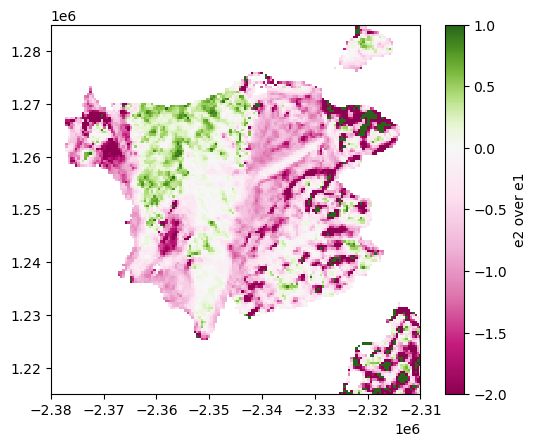

In [12]:
# numpy gradient function returns gradientient in rows and then columns direction for 2D input
# l_ij denotes components of the velocity gradient tensor and e_ij denotes components of the strain
# rate tensor. l_xx and l_yy are same as e_xx and e_yy (because on diagonal), but e_xy is 1/2*(l_xy + l_yx).
# See strain-rate tensor wiki.
del_X = X[1] - X[0]
del_Y = Y[1] - Y[0]

l_XY, e_XX = np.gradient(VX, del_X, del_Y)
e_YY, l_YX = np.gradient(VY, del_X, del_Y)
e_XY = 0.5 * (l_XY + l_YX) # the shear strain rate 

e_1, e_2 = eig_2D_sym(e_XX, e_YY, e_XY)
min_over_max_spatial = e_2/e_1
min_over_max_spatial[mask!=3] = np.nan

# make the asymetric colorbar from -2 to +1
PiYG_cool = plt.cm.PiYG.resampled(256)
PiYG_hot = plt.cm.PiYG.resampled(128)
PiYG_cool_colors = PiYG_cool(np.linspace(0,1,256))
PiYG_hot_colors = np.flipud(PiYG_hot(np.linspace(0,1,128)))
PiYG_asym_colors = np.concatenate((PiYG_cool_colors[0:128,:], np.flipud(PiYG_hot_colors[0:64,:])))
PiYG_asym = mpl.colors.ListedColormap(PiYG_asym_colors)

#plot
fig, axs = plt.subplots(1,1)
axs.set_aspect('equal')
e1e2_pc = axs.pcolormesh(X, Y, min_over_max_spatial, vmin=-2.0, vmax=1.0, shading='nearest', cmap=PiYG_asym)
fig.colorbar(e1e2_pc, ax=axs, label='e2 over e1')
axs.set_xlim(x_min, x_max)
axs.set_ylim(y_min, y_max)

In [13]:

# do crevasse calculations with each calculation version (A through F)
ds_A, db_A = nyeCrevassesAF(X, Y, VX, VY, surf, thk, Tsurf, Tbase, rho_i, rho_pw, g, 'A')[0:2] # [0:2] request the first two returns (crev sizes)
ds_B, db_B = nyeCrevassesAF(X, Y, VX, VY, surf, thk, Tsurf, Tbase, rho_i, rho_pw, g, 'B')[0:2]
ds_C, db_C = nyeCrevassesAF(X, Y, VX, VY, surf, thk, Tsurf, Tbase, rho_i, rho_pw, g, 'C')[0:2]
ds_D, db_D = nyeCrevassesAF(X, Y, VX, VY, surf, thk, Tsurf, Tbase, rho_i, rho_pw, g, 'D')[0:2]
ds_E, db_E = nyeCrevassesAF(X, Y, VX, VY, surf, thk, Tsurf, Tbase, rho_i, rho_pw, g, 'E')[0:2]
ds_F, db_F, Rxx_s, tau_xx_s, tau_yy_s, Rxx_b, tau_xx_b, tau_yy_b = nyeCrevassesAF(X, Y, VX, VY, surf, thk, Tsurf, Tbase, rho_i, rho_pw, g, 'F')

# calculate crevasse penetration ratio for each calculationversion
pen_rat_A = calcPenRatio(ds_A, db_A, thk)
pen_rat_B = calcPenRatio(ds_B, db_B, thk)
pen_rat_C = calcPenRatio(ds_C, db_C, thk)
pen_rat_D = calcPenRatio(ds_D, db_D, thk)
pen_rat_E = calcPenRatio(ds_E, db_E, thk)
pen_rat_F = calcPenRatio(ds_F, db_F, thk)

(1215000.0, 1285000.0)

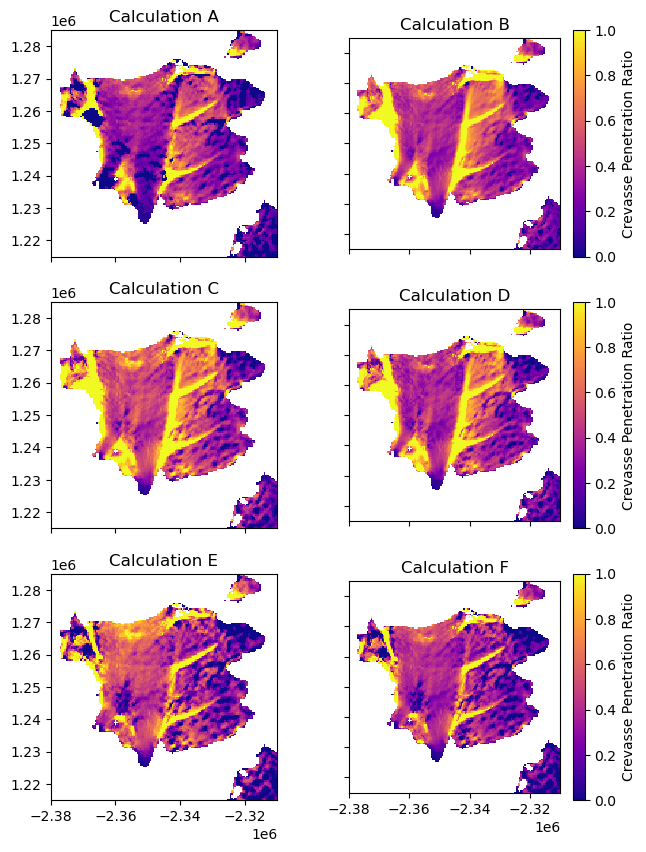

In [14]:
# Plot calculations A through F

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, figsize=(7.5,10))

axs[0,0].pcolormesh(X, Y, pen_rat_A, vmin=0.0, vmax=1.0, shading='nearest', cmap=plt.cm.plasma)
axs[0,0].set_title('Calculation A')
axs[0,0].set_aspect('equal')

pcmB = axs[0,1].pcolormesh(X, Y, pen_rat_B, vmin=0.0, vmax=1.0, shading='nearest', cmap=plt.cm.plasma)
axs[0,1].set_title('Calculation B')
axs[0,1].set_aspect('equal')
fig.colorbar(pcmB, ax=axs[0,1], label='Crevasse Penetration Ratio')

axs[1,0].pcolormesh(X, Y, pen_rat_C, vmin=0.0, vmax=1.0, shading='nearest', cmap=plt.cm.plasma)
axs[1,0].set_title('Calculation C')
axs[1,0].set_aspect('equal')

pcmD = axs[1,1].pcolormesh(X, Y, pen_rat_D, vmin=0.0, vmax=1.0, shading='nearest', cmap=plt.cm.plasma)
axs[1,1].set_title('Calculation D')
axs[1,1].set_aspect('equal')
fig.colorbar(pcmD, ax=axs[1,1], label='Crevasse Penetration Ratio')

axs[2,0].pcolormesh(X, Y, pen_rat_E, vmin=0.0, vmax=1.0, shading='nearest', cmap=plt.cm.plasma)
axs[2,0].set_title('Calculation E')
axs[2,0].set_aspect('equal')

pcmF = axs[2,1].pcolormesh(X, Y, pen_rat_F, vmin=0.0, vmax=1.0, shading='nearest', cmap=plt.cm.plasma)
axs[2,1].set_title('Calculation F')
axs[2,1].set_aspect('equal')
fig.colorbar(pcmF, ax=axs[2,1], label='Crevasse Penetration Ratio')
axs[2,1].set_xlim(x_min, x_max)
axs[2,1].set_ylim(y_min, y_max)

(1215000.0, 1285000.0)

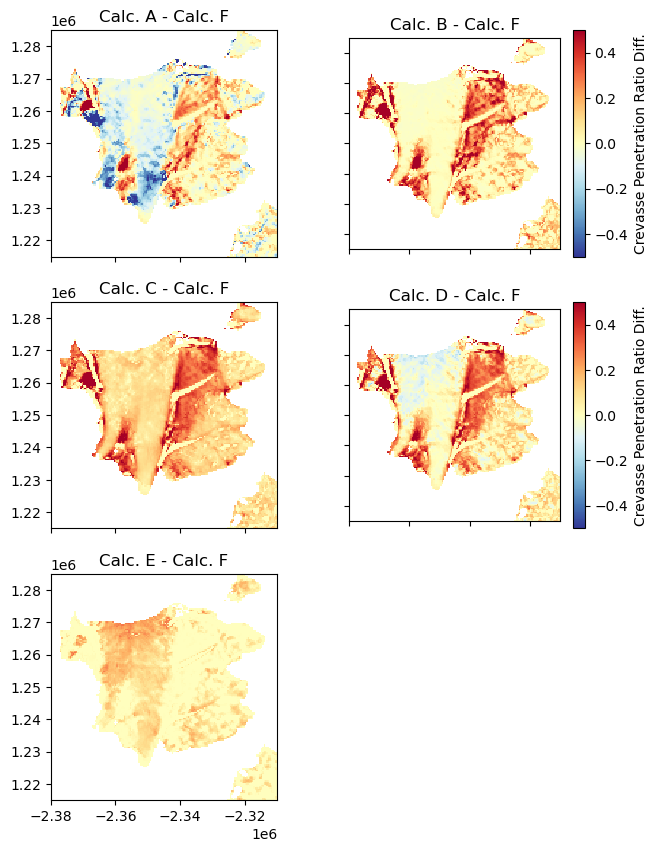

In [15]:
# Plot calculations A through F

div_cmap = plt.cm.RdYlBu
div_cmap = div_cmap.reversed()

fig, axs = plt.subplots(3, 2, sharex=True, sharey=True, figsize=(7.5,10))

axs[0,0].pcolormesh(X, Y, pen_rat_A-pen_rat_F, vmin=-0.5, vmax=0.5, shading='nearest', cmap=div_cmap)
axs[0,0].set_title('Calc. A - Calc. F')
axs[0,0].set_aspect('equal')

pcmB = axs[0,1].pcolormesh(X, Y, pen_rat_B-pen_rat_F, vmin=-0.5, vmax=0.5, shading='nearest', cmap=div_cmap)
axs[0,1].set_title('Calc. B - Calc. F')
axs[0,1].set_aspect('equal')
fig.colorbar(pcmB, ax=axs[0,1], label='Crevasse Penetration Ratio Diff.')

axs[1,0].pcolormesh(X, Y, pen_rat_C-pen_rat_F, vmin=-0.5, vmax=0.5, shading='nearest', cmap=div_cmap)
axs[1,0].set_title('Calc. C - Calc. F')
axs[1,0].set_aspect('equal')

pcmD = axs[1,1].pcolormesh(X, Y, pen_rat_D-pen_rat_F, vmin=-0.5, vmax=0.5, shading='nearest', cmap=div_cmap)
axs[1,1].set_title('Calc. D - Calc. F')
axs[1,1].set_aspect('equal')
fig.colorbar(pcmD, ax=axs[1,1], label='Crevasse Penetration Ratio Diff.')

axs[2,0].pcolormesh(X, Y, pen_rat_E-pen_rat_F, vmin=-0.5, vmax=0.5, shading='nearest', cmap=div_cmap)
axs[2,0].set_title('Calc. E - Calc. F')
axs[2,0].set_aspect('equal')

axs[2,1].axis("off")

axs[0,0].set_xlim(x_min, x_max)
axs[0,0].set_ylim(y_min, y_max)